Уникальных навыков: 229
Всего упоминаний: 2057


C:\Users\максим\AppData\Local\Temp\ipykernel_6548\3801352768.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=skills, palette="viridis")


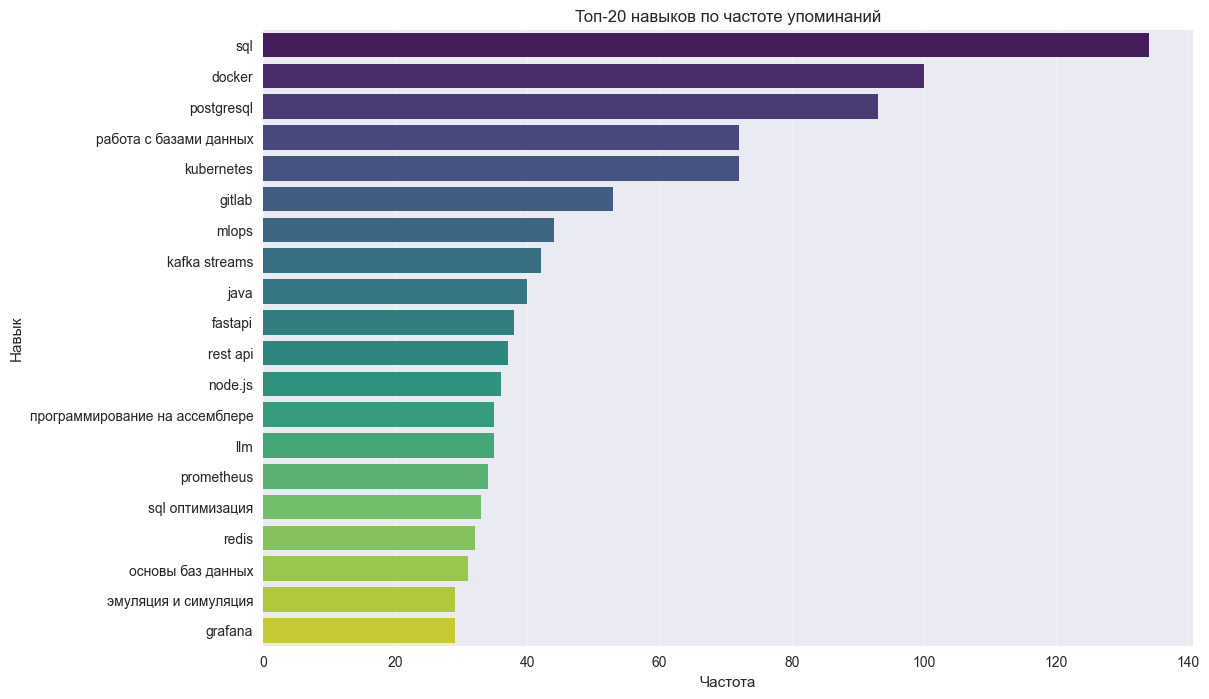

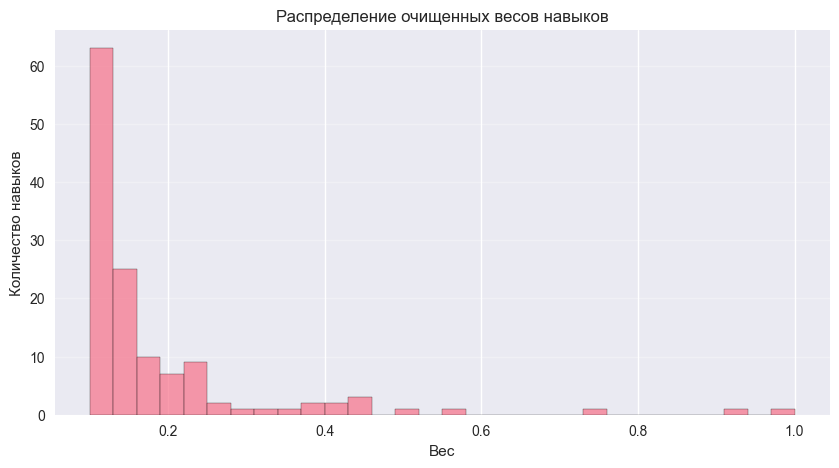

c:\Users\максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


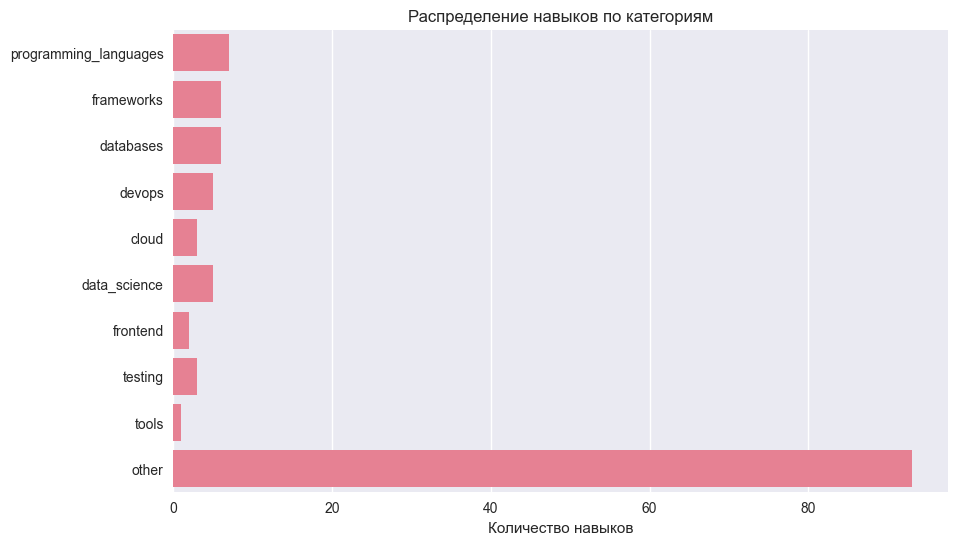

In [1]:
# %% [markdown]
# # Анализ рынка труда: частоты, гибридные веса, распределения

# %%
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

from src.config import DATA_PROCESSED_DIR, MODELS_DIR
from src.visualization.charts import load_skill_weights, load_hybrid_weights, plot_weight_distribution

# %%
# Загрузка данных
freq_path = DATA_PROCESSED_DIR / "competency_frequency.json"
with open(freq_path, 'r', encoding='utf-8') as f:
    skill_freq = json.load(f)

skill_weights = load_skill_weights()
hybrid_weights = load_hybrid_weights()

print(f"Уникальных навыков: {len(skill_freq)}")
print(f"Всего упоминаний: {sum(skill_freq.values())}")

# %%
# Топ-20 по частоте
top_freq = sorted(skill_freq.items(), key=lambda x: x[1], reverse=True)[:20]
skills, counts = zip(*top_freq)

plt.figure(figsize=(12, 8))
sns.barplot(x=counts, y=skills, palette="viridis")
plt.title("Топ-20 навыков по частоте упоминаний")
plt.xlabel("Частота")
plt.ylabel("Навык")
plt.grid(axis='x', alpha=0.3)
plt.show()

# %%
# Гибридные веса (если есть)
if hybrid_weights:
    top_hybrid = sorted(hybrid_weights.items(), key=lambda x: x[1], reverse=True)[:20]
    skills_h, weights_h = zip(*top_hybrid)
    plt.figure(figsize=(12, 8))
    sns.barplot(x=weights_h, y=skills_h, palette="plasma")
    plt.title("Топ-20 навыков по гибридному весу (BM25 + эмбеддинги)")
    plt.xlabel("Гибридный вес")
    plt.ylabel("Навык")
    plt.grid(axis='x', alpha=0.3)
    plt.show()

# %%
# Распределение весов
plot_weight_distribution(skill_weights, "Распределение очищенных весов навыков")
plt.show()

# %%
# Анализ категорий навыков (опционально, если есть skill_filter)
from src.analyzers.skill_filter import SkillFilter
sf = SkillFilter()
categories = sf.get_skill_categories(list(skill_weights.keys()))
cat_counts = {cat: len(skills) for cat, skills in categories.items()}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(cat_counts.values()), y=list(cat_counts.keys()))
plt.title("Распределение навыков по категориям")
plt.xlabel("Количество навыков")
plt.show()